In [4]:
# import libraries
import numpy as np
import pandas as pd
import seaborn as sns

import matplotlib
import matplotlib.pyplot as plt
plt.style.use('ggplot')
from matplotlib.pyplot import figure

%matplotlib inline
matplotlib.rcParams['figure.figsize'] = (12, 8)  # Adjusts the configurationof the plots we will create

# read in the data
path = r'C:\Users\User\Desktop\David-the-analyst-portfolio-projects\Movie Correlation Project\movies.csv'
df = pd.read_csv(path)


In [2]:
# lets look at the data
df.head()


,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime
0,The Shining,R,Drama,1980,"June 13, 1980 (United States)",8.4,927000.0,Stanley Kubrick,Stephen King,Jack Nicholson,United Kingdom,19000000.0,46998772.0,Warner Bros.,146.0
1,The Blue Lagoon,R,Adventure,1980,"July 2, 1980 (United States)",5.8,65000.0,Randal Kleiser,Henry De Vere Stacpoole,Brooke Shields,United States,4500000.0,58853106.0,Columbia Pictures,104.0
2,Star Wars: Episode V - The Empire Strikes Back,PG,Action,1980,"June 20, 1980 (United States)",8.7,1200000.0,Irvin Kershner,Leigh Brackett,Mark Hamill,United States,18000000.0,538375067.0,Lucasfilm,124.0
3,Airplane!,PG,Comedy,1980,"July 2, 1980 (United States)",7.7,221000.0,Jim Abrahams,Jim Abrahams,Robert Hays,United States,3500000.0,83453539.0,Paramount Pictures,88.0
4,Caddyshack,R,Comedy,1980,"July 25, 1980 (United States)",7.3,108000.0,Harold Ramis,Brian Doyle-Murray,Chevy Chase,United States,6000000.0,39846344.0,Orion Pictures,98.0


In [4]:
# Lets see if there's any missing data
# so we can start data cleaning
# there are lots of ways to do this

for col in df.columns:
    pct_missing = np.mean(df[col].isnull())
    # print('{} - {}%'.format(col, pct_missing))
    print(f"{col} - {pct_missing}")


name - 0.0
rating - 0.010041731872717789
genre - 0.0
year - 0.0
released - 0.0002608242044861763
score - 0.0003912363067292645
votes - 0.0003912363067292645
director - 0.0
writer - 0.0003912363067292645
star - 0.00013041210224308815
country - 0.0003912363067292645
budget - 0.2831246739697444
gross - 0.02464788732394366
company - 0.002217005738132499
runtime - 0.0005216484089723526


In [5]:
# for col in df.columns:
#     print(df[col])

In [6]:
# Data types for our columns

df.dtypes

name         object
rating       object
genre        object
year          int64
released     object
score       float64
votes       float64
director     object
writer       object
star         object
country      object
budget      float64
gross       float64
company      object
runtime     float64
dtype: object

In [ ]:
# to fill in empty cells with data
# fill all text (object) columns with 'Unknown'
text_cols = df.select_dtypes(include=['object']).columns
df[text_cols] = df[text_cols].fillna('Unknown')

# fill all numeric columns with the column's mean
num_cols = df.select_dtypes(include=['number']).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].mean())


In [8]:
# change data type of columns
df['budget'] = df['budget'].astype('int64')
df['gross'] = df['gross'].astype('int64')

In [9]:
df.head()

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime
0,The Shining,R,Drama,1980,"June 13, 1980 (United States)",8.4,927000.0,Stanley Kubrick,Stephen King,Jack Nicholson,United Kingdom,19000000,46998772,Warner Bros.,146.0
1,The Blue Lagoon,R,Adventure,1980,"July 2, 1980 (United States)",5.8,65000.0,Randal Kleiser,Henry De Vere Stacpoole,Brooke Shields,United States,4500000,58853106,Columbia Pictures,104.0
2,Star Wars: Episode V - The Empire Strikes Back,PG,Action,1980,"June 20, 1980 (United States)",8.7,1200000.0,Irvin Kershner,Leigh Brackett,Mark Hamill,United States,18000000,538375067,Lucasfilm,124.0
3,Airplane!,PG,Comedy,1980,"July 2, 1980 (United States)",7.7,221000.0,Jim Abrahams,Jim Abrahams,Robert Hays,United States,3500000,83453539,Paramount Pictures,88.0
4,Caddyshack,R,Comedy,1980,"July 25, 1980 (United States)",7.3,108000.0,Harold Ramis,Brian Doyle-Murray,Chevy Chase,United States,6000000,39846344,Orion Pictures,98.0


In [34]:
df['Year Corrected'] = df['released'].astype(str).str[:4]
df.head()

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime,Year Corrected
5445,533,5,0,2009,696,7.8,1100000.0,1155,1778,2334,55,237000000,2847246203,2253,162.0,696
7445,535,5,0,2019,183,8.4,903000.0,162,743,2241,55,356000000,2797501328,1606,181.0,183
3045,6896,5,6,1997,704,7.8,1100000.0,1155,1778,1595,55,200000000,2201647264,2253,194.0,704
6663,5144,5,0,2015,698,7.8,876000.0,1125,2550,524,55,245000000,2069521700,1540,138.0,698
7244,536,5,0,2018,192,8.4,897000.0,162,743,2241,55,321000000,2048359754,1606,149.0,192


In [11]:
df = df.sort_values(by=['gross'], inplace=False, ascending=False)


In [12]:
# drop any duplicates
df['company'].drop_duplicates()
# df['company'].drop_duplicates().sort_values(ascending=False) --- drop duplicates and sort descending

5445        Twentieth Century Fox
7445               Marvel Studios
6663                    Lucasfilm
7480         Walt Disney Pictures
6653           Universal Pictures
                  ...            
6030                 Process Film
5524          Cinema Libre Studio
2906         Balboa Entertainment
7625    Visual Arts Entertainment
3203                     Daybreak
Name: company, Length: 2386, dtype: object

In [33]:
df.head()

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime,Year Corrected
5445,533,5,0,2009,696,7.8,1100000.0,1155,1778,2334,55,237000000,2847246203,2253,162.0,10
7445,535,5,0,2019,183,8.4,903000.0,162,743,2241,55,356000000,2797501328,1606,181.0,8
3045,6896,5,6,1997,704,7.8,1100000.0,1155,1778,1595,55,200000000,2201647264,2253,194.0,10
6663,5144,5,0,2015,698,7.8,876000.0,1125,2550,524,55,245000000,2069521700,1540,138.0,10
7244,536,5,0,2018,192,8.4,897000.0,162,743,2241,55,321000000,2048359754,1606,149.0,8


In [14]:
# Budget high correlation
# Company high correlation


Text(0, 0.5, 'Budget for Films')

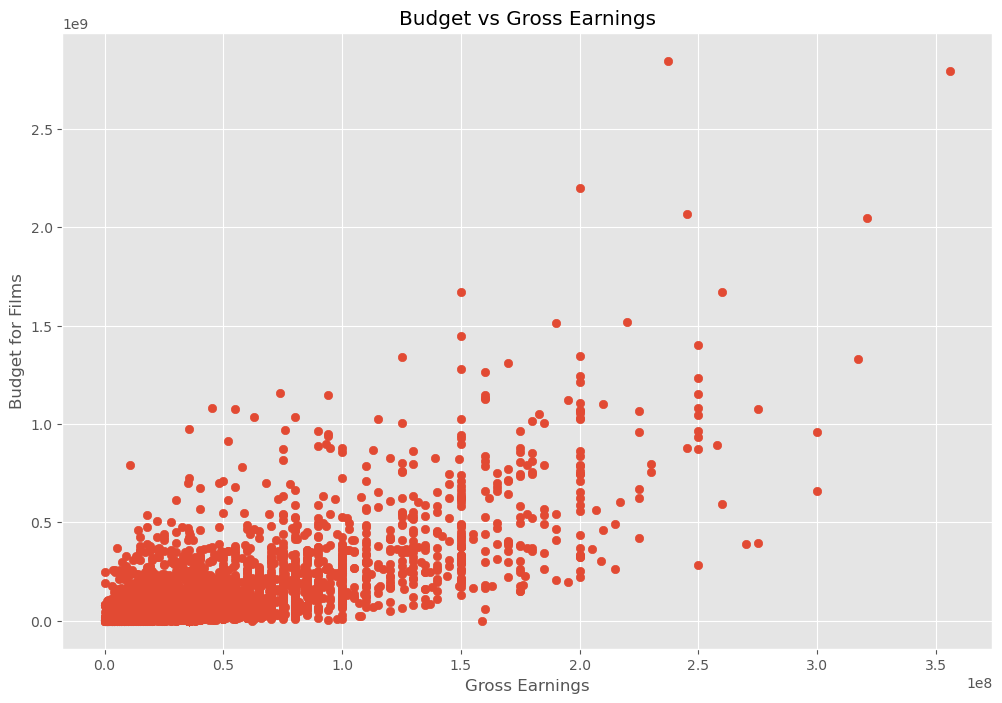

In [15]:
# Scatter plot with budget vs gross

plt.scatter(x=df['budget'], y=df['gross'])
plt.title('Budget vs Gross Earnings')
plt.xlabel('Gross Earnings')
plt.ylabel('Budget for Films')
# plt.show() -- not necessary but necessary at the same time

In [16]:
df.head()

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime,Year Corrected
5445,Avatar,PG-13,Action,2009,"December 18, 2009 (United States)",7.8,1100000.0,James Cameron,James Cameron,Sam Worthington,United States,237000000,2847246203,Twentieth Century Fox,162.0,Dece
7445,Avengers: Endgame,PG-13,Action,2019,"April 26, 2019 (United States)",8.4,903000.0,Anthony Russo,Christopher Markus,Robert Downey Jr.,United States,356000000,2797501328,Marvel Studios,181.0,Apri
3045,Titanic,PG-13,Drama,1997,"December 19, 1997 (United States)",7.8,1100000.0,James Cameron,James Cameron,Leonardo DiCaprio,United States,200000000,2201647264,Twentieth Century Fox,194.0,Dece
6663,Star Wars: Episode VII - The Force Awakens,PG-13,Action,2015,"December 18, 2015 (United States)",7.8,876000.0,J.J. Abrams,Lawrence Kasdan,Daisy Ridley,United States,245000000,2069521700,Lucasfilm,138.0,Dece
7244,Avengers: Infinity War,PG-13,Action,2018,"April 27, 2018 (United States)",8.4,897000.0,Anthony Russo,Christopher Markus,Robert Downey Jr.,United States,321000000,2048359754,Marvel Studios,149.0,Apri


<Axes: xlabel='budget', ylabel='gross'>

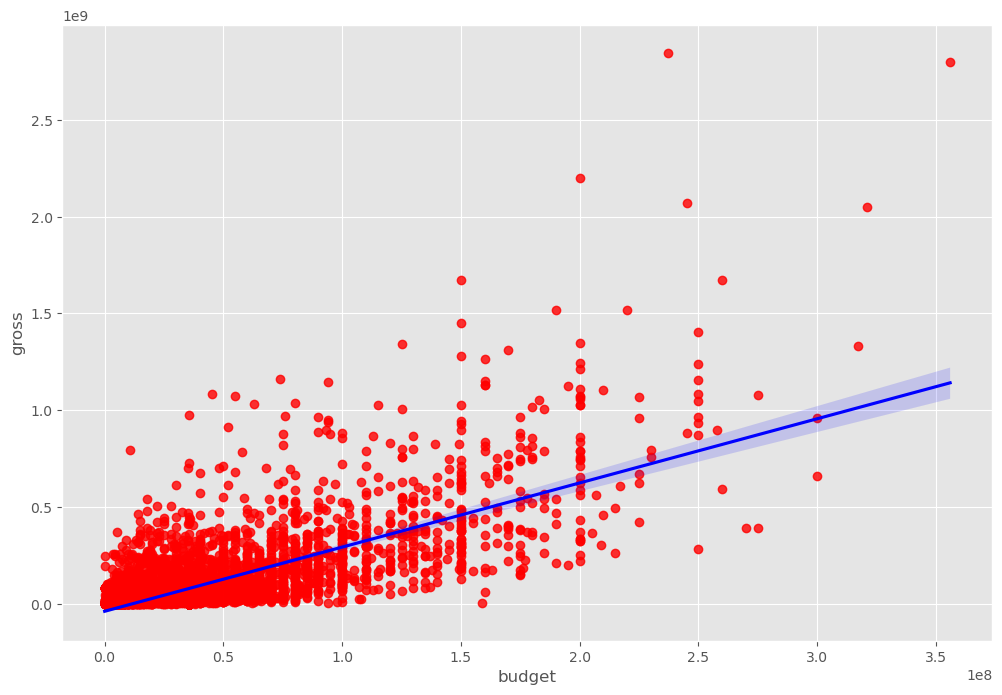

In [17]:
# Plot budget vs gross using seaborn

# sns.regplot(x=df['budget'], y=df['gross']) -- OR
sns.regplot(x='budget', y='gross', data=df, scatter_kws={"color":"red"}, line_kws={"color":"blue"})
# plt.show() -- not necessary

In [18]:
# Lets start looking at correlation

In [19]:
df.corr(method='pearson' ,numeric_only=True) #methods of correl. = pearson, kendall, spearman
# here for pearson the correlations are all +ve correlations

,year,score,votes,budget,gross,runtime
year,1.000000,0.097936,0.222810,0.265578,0.252042,0.120766
score,0.097936,1.000000,0.409182,0.064541,0.182868,0.399329
votes,0.222810,0.409182,1.000000,0.421007,0.628713,0.309166
budget,0.265578,0.064541,0.421007,1.000000,0.711270,0.265287
gross,0.252042,0.182868,0.628713,0.711270,1.000000,0.241335
runtime,0.120766,0.399329,0.309166,0.265287,0.241335,1.000000


In [20]:
# from the correlation matrix above there's High correlation between budget and gross

Text(120.72222222222221, 0.5, 'Budget for Film')

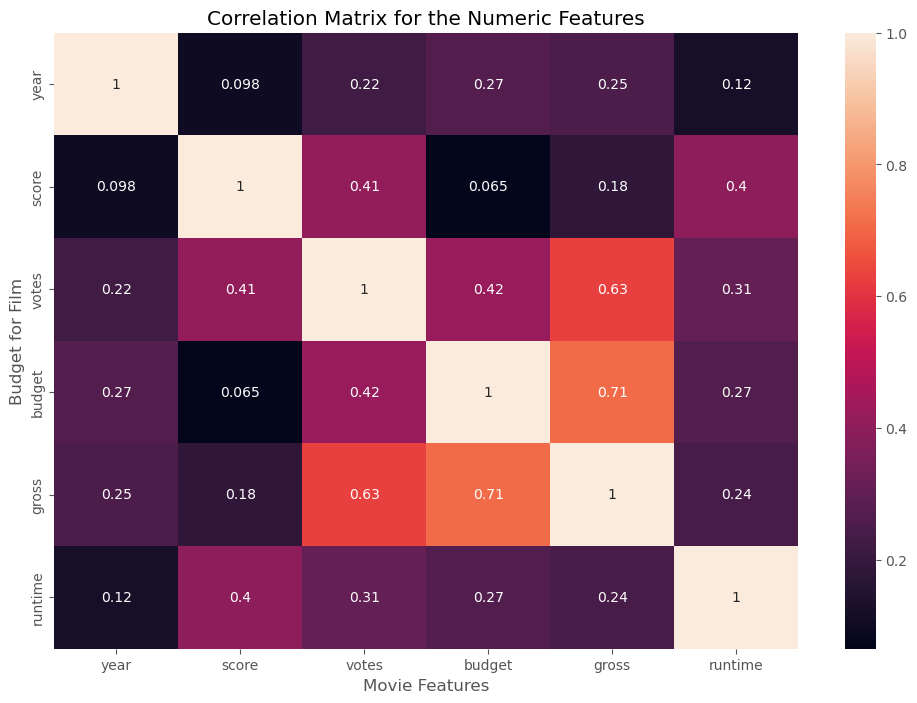

In [21]:
# we want to visualize the correlation matrix above
correlation_matrix = df.corr(method='pearson', numeric_only=True)
sns.heatmap(correlation_matrix, annot=True)
plt.title('Correlation Matrix for the Numeric Features')
plt.xlabel('Movie Features')
plt.ylabel('Budget for Film')
# plt.show() -- not necessary


In [22]:
# Looks at Company
df.head()

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime,Year Corrected
5445,Avatar,PG-13,Action,2009,"December 18, 2009 (United States)",7.8,1100000.0,James Cameron,James Cameron,Sam Worthington,United States,237000000,2847246203,Twentieth Century Fox,162.0,Dece
7445,Avengers: Endgame,PG-13,Action,2019,"April 26, 2019 (United States)",8.4,903000.0,Anthony Russo,Christopher Markus,Robert Downey Jr.,United States,356000000,2797501328,Marvel Studios,181.0,Apri
3045,Titanic,PG-13,Drama,1997,"December 19, 1997 (United States)",7.8,1100000.0,James Cameron,James Cameron,Leonardo DiCaprio,United States,200000000,2201647264,Twentieth Century Fox,194.0,Dece
6663,Star Wars: Episode VII - The Force Awakens,PG-13,Action,2015,"December 18, 2015 (United States)",7.8,876000.0,J.J. Abrams,Lawrence Kasdan,Daisy Ridley,United States,245000000,2069521700,Lucasfilm,138.0,Dece
7244,Avengers: Infinity War,PG-13,Action,2018,"April 27, 2018 (United States)",8.4,897000.0,Anthony Russo,Christopher Markus,Robert Downey Jr.,United States,321000000,2048359754,Marvel Studios,149.0,Apri


In [23]:
# since company is a string, we have to make it to be represented as numeric in the correlation

In [32]:
df_numerized = df
# so we want to do it for all columns(i.e the text columns like 'Company')
for col_name in df_numerized.columns:
    if(df_numerized[col_name].dtype == 'object'):
        df_numerized[col_name] = df_numerized[col_name].astype('category')
        df_numerized[col_name] = df_numerized[col_name].cat.codes
df_numerized.head()

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime,Year Corrected
5445,533,5,0,2009,696,7.8,1100000.0,1155,1778,2334,55,237000000,2847246203,2253,162.0,10
7445,535,5,0,2019,183,8.4,903000.0,162,743,2241,55,356000000,2797501328,1606,181.0,8
3045,6896,5,6,1997,704,7.8,1100000.0,1155,1778,1595,55,200000000,2201647264,2253,194.0,10
6663,5144,5,0,2015,698,7.8,876000.0,1125,2550,524,55,245000000,2069521700,1540,138.0,10
7244,536,5,0,2018,192,8.4,897000.0,162,743,2241,55,321000000,2048359754,1606,149.0,8


In [25]:
df.head()

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime,Year Corrected
5445,533,5,0,2009,696,7.8,1100000.0,1155,1778,2334,55,237000000,2847246203,2253,162.0,10
7445,535,5,0,2019,183,8.4,903000.0,162,743,2241,55,356000000,2797501328,1606,181.0,8
3045,6896,5,6,1997,704,7.8,1100000.0,1155,1778,1595,55,200000000,2201647264,2253,194.0,10
6663,5144,5,0,2015,698,7.8,876000.0,1125,2550,524,55,245000000,2069521700,1540,138.0,10
7244,536,5,0,2018,192,8.4,897000.0,162,743,2241,55,321000000,2048359754,1606,149.0,8


Text(120.72222222222221, 0.5, 'Movie Features')

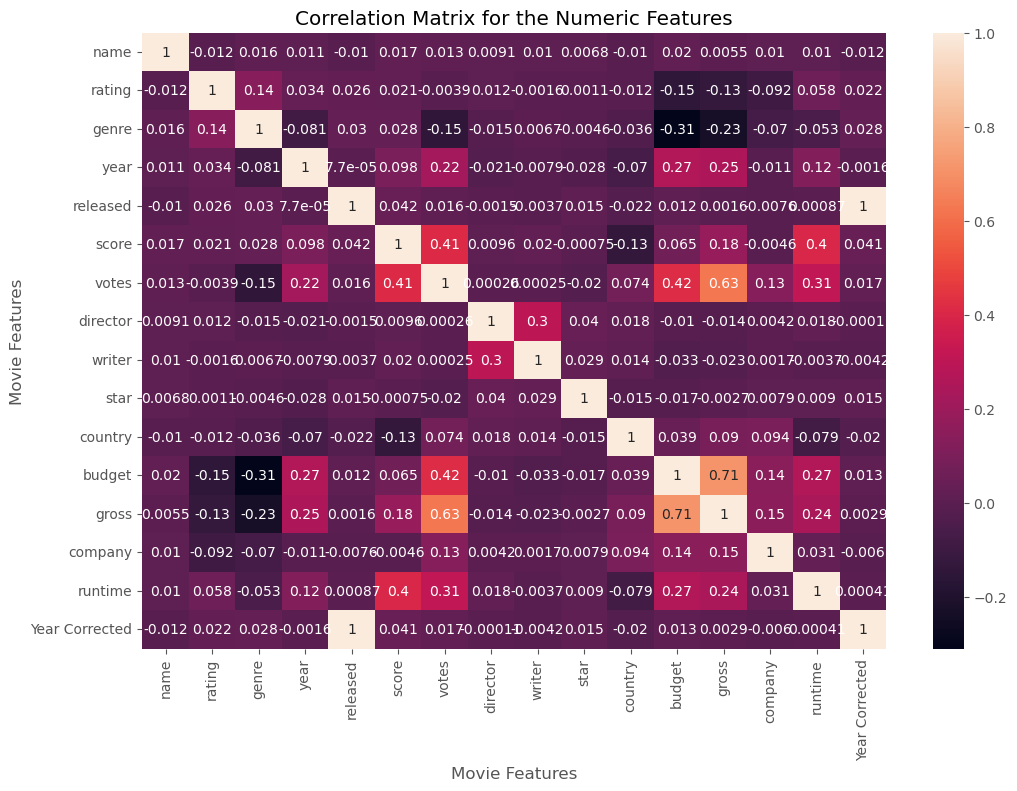

In [26]:
correlation_matrix = df_numerized.corr(method='pearson', numeric_only=True)
sns.heatmap(correlation_matrix, annot=True)
plt.title('Correlation Matrix for the Numeric Features')
plt.xlabel('Movie Features')
plt.ylabel('Movie Features')
# plt.show() -- not necessary


In [27]:
df_numerized.corr()

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime,Year Corrected
name,1.000000,-0.012206,0.016355,0.011453,-0.010480,0.017095,0.013086,0.009079,0.009985,0.006844,-0.010359,0.020368,0.005466,0.010373,0.010390,-0.011725
rating,-0.012206,1.000000,0.136127,0.033801,0.025526,0.020968,-0.003862,0.011951,-0.001610,0.001063,-0.011793,-0.150081,-0.127190,-0.092284,0.058132,0.022426
genre,0.016355,0.136127,1.000000,-0.081261,0.030429,0.027959,-0.145276,-0.015258,0.006747,-0.004641,-0.035783,-0.310566,-0.230267,-0.070032,-0.052699,0.028397
year,0.011453,0.033801,-0.081261,1.000000,0.000077,0.097936,0.222810,-0.020795,-0.007930,-0.027912,-0.069590,0.265578,0.252042,-0.011425,0.120766,-0.001562
released,-0.010480,0.025526,0.030429,0.000077,1.000000,0.042140,0.016151,-0.001526,-0.003707,0.015474,-0.021707,0.012263,0.001636,-0.007634,0.000867,0.995320
score,0.017095,0.020968,0.027959,0.097936,0.042140,1.000000,0.409182,0.009559,0.019787,-0.000754,-0.134447,0.064541,0.182868,-0.004584,0.399329,0.040983
votes,0.013086,-0.003862,-0.145276,0.222810,0.016151,0.409182,1.000000,0.000260,0.000252,-0.019510,0.073521,0.421007,0.628713,0.130659,0.309166,0.017333
director,0.009079,0.011951,-0.015258,-0.020795,-0.001526,0.009559,0.000260,1.000000,0.299523,0.039875,0.018014,-0.010364,-0.014272,0.004248,0.017624,-0.000105
writer,0.009985,-0.001610,0.006747,-0.007930,-0.003707,0.019787,0.000252,0.299523,1.000000,0.028887,0.014490,-0.033223,-0.023192,0.001729,-0.003692,-0.004193
star,0.006844,0.001063,-0.004641,-0.027912,0.015474,-0.000754,-0.019510,0.039875,0.028887,1.000000,-0.015101,-0.017056,-0.002678,0.007918,0.008957,0.015093


In [28]:
# A better way to visualize the correlation making it easier to read is using the 'unstack()'
correlation_mat = df_numerized.corr()
corr_pairs = pd.set_option('display.max_rows', None)
corr_pairs = correlation_mat.unstack()
corr_pairs

name            name              1.000000
                rating           -0.012206
                genre             0.016355
                year              0.011453
                released         -0.010480
                score             0.017095
                votes             0.013086
                director          0.009079
                writer            0.009985
                star              0.006844
                country          -0.010359
                budget            0.020368
                gross             0.005466
                company           0.010373
                runtime           0.010390
                Year Corrected   -0.011725
rating          name             -0.012206
                rating            1.000000
                genre             0.136127
                year              0.033801
                released          0.025526
                score             0.020968
                votes            -0.003862
           

In [29]:
# Or
sorted_pairs = corr_pairs.sort_values()
sorted_pairs

genre           budget           -0.310566
budget          genre            -0.310566
gross           genre            -0.230267
genre           gross            -0.230267
rating          budget           -0.150081
budget          rating           -0.150081
votes           genre            -0.145276
genre           votes            -0.145276
country         score            -0.134447
score           country          -0.134447
rating          gross            -0.127190
gross           rating           -0.127190
company         rating           -0.092284
rating          company          -0.092284
genre           year             -0.081261
year            genre            -0.081261
country         runtime          -0.079188
runtime         country          -0.079188
genre           company          -0.070032
company         genre            -0.070032
country         year             -0.069590
year            country          -0.069590
genre           runtime          -0.052699
runtime    

In [30]:
high_corr = sorted_pairs[(sorted_pairs) > 0.5]
high_corr.head() # the ones that are equal to 1.000 dont matter

gross     votes             0.628713
votes     gross             0.628713
gross     budget            0.711270
budget    gross             0.711270
released  Year Corrected    0.995320
dtype: float64

In [31]:
# Votes and budget have the highest correlation to gross earnings
# follow by budget and gross
# Company has Low correlation